# Churn Prediction Project
For the first part we will:
1. Download and read the data;
2. Take a quick look at the data;
3. Make column names and values look uniform by applying simple normalization;
4. Check if all the columns are correct;
5. Check if churn variable need any preparation.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
PATH = '../../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [14]:
df = pd.read_csv(PATH)

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
df.shape

(7043, 21)

In [17]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [18]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [19]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [20]:
df.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn                object
dtype: object

In [21]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

In [25]:
df['totalcharges'] = df['totalcharges'].fillna(0.0)

In [26]:
df['churn'][:5]

0     no
1     no
2    yes
3     no
4    yes
Name: churn, dtype: object

In [27]:
df['churn'].isnull().sum()

np.int64(0)

In [28]:
df['churn'] = (df['churn'] == 'yes').astype(int)

In [29]:
df['churn'][:5]

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

## Setting Up the Validation Framework
For this part we wil use Scikit-learn to perform train/test/validation split.

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
# First, we split the data for the independent variables
# With that, we get the test dataset.
X_full_tr, X_ts = train_test_split(df, test_size=0.2, random_state=1)

In [32]:
# Here, we take the full training dataset and split one more time to get the validation dataset
X_tr, X_val = train_test_split(X_full_tr, test_size=0.25, random_state=1)

In [33]:
X_tr.shape, X_ts.shape, X_val.shape

((4225, 21), (1409, 21), (1409, 21))

In [34]:
X_tr = X_tr.reset_index(drop=True)
X_ts = X_ts.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)

In [35]:
# Dependet variable (the one we want to predict)
y_tr = X_tr['churn'].values
y_ts = X_ts['churn'].values
y_val = X_val['churn'].values

In [36]:
# Removing the dependent variable from the X dataset.
del X_tr['churn']
del X_ts['churn']
del X_val['churn']

## EDA
- Check missing values
- Look a the target variable
- Look at numerical and categorical variables

In [37]:
X_full_tr = X_full_tr.reset_index(drop=True)

In [38]:
X_full_tr.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [39]:
X_full_tr.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [40]:
X_full_tr['churn'].value_counts()

churn
0    4113
1    1521
Name: count, dtype: int64

In [41]:
round(X_full_tr['churn'].value_counts(normalize=True), 2)

churn
0    0.73
1    0.27
Name: proportion, dtype: float64

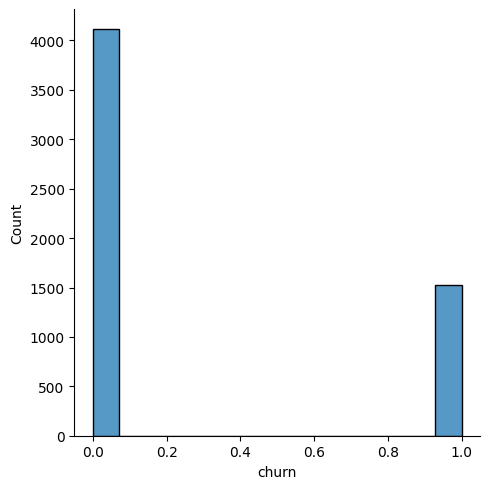

In [42]:
sns.displot(X_full_tr['churn']);

In [43]:
X_full_tr.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [44]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [45]:
X_full_tr.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [46]:
categorical = X_full_tr.select_dtypes(include=['object']).columns.tolist()

In [47]:
categorical

['customerid',
 'gender',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [48]:
X_full_tr[categorical].nunique()

customerid          5634
gender                 2
partner                2
dependents             2
phoneservice           2
multiplelines          3
internetservice        3
onlinesecurity         3
onlinebackup           3
deviceprotection       3
techsupport            3
streamingtv            3
streamingmovies        3
contract               3
paperlessbilling       2
paymentmethod          4
dtype: int64

### Feature Importance: Churn Rate and Risk Ration
Feature Importance analysis (EDA). Identify which features affect our target variable
- Churn Rate
- Risk Ration
- Mutual Information

In [49]:
churn_female = X_full_tr[X_full_tr['gender'] == 'female']['churn'].mean()
churn_female

np.float64(0.27682403433476394)

In [50]:
churn_male = X_full_tr[X_full_tr['gender'] == 'male']['churn'].mean()
churn_male

np.float64(0.2632135306553911)

In [51]:
# Another way
X_full_tr.groupby('gender')['churn'].mean()

gender
female    0.276824
male      0.263214
Name: churn, dtype: float64

In [52]:
global_churn = X_full_tr['churn'].mean()
global_churn

np.float64(0.26996805111821087)

In [53]:
with_partner = X_full_tr[X_full_tr['partner'] == 'yes']['churn'].mean()
with_partner

np.float64(0.20503330866025166)

In [54]:
without_partner = X_full_tr[X_full_tr['partner'] == 'no']['churn'].mean()
without_partner

np.float64(0.3298090040927694)

In [55]:
X_full_tr.groupby('partner')['churn'].mean()

partner
no     0.329809
yes    0.205033
Name: churn, dtype: float64

There is a reason why we did this.
1. If the _difference_ between `Global - Group > 0`, the group is less likely to churn.
2. If the _difference_ between `Global - Group < 0`, the group is more lekely to churn.
3. If we divide a group by the global the result will be a ratio that tells us which group is more likely to churn. If the ratio is > 1 the group is more likely to churn. If the ratio is < 1, the group is less likely to churn.

Those approaches tells us basically the same information, but in different ways.

In [56]:
df_result = X_full_tr.groupby('gender')['churn'].agg(['mean', 'count'])

In [57]:
df_result['diff'] = df_result['mean'] - global_churn
df_result['risk'] = df_result['mean'] / global_churn

display(df_result)

,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980


In [58]:
X_full_tr = X_full_tr.drop('customerid', axis=1)

In [59]:
if 'customerid' in categorical:
    categorical.remove('customerid')


for c in categorical:
    print(c)
    df_result = X_full_tr.groupby(c)['churn'].agg(['mean', 'count'])
    df_result['diff'] = df_result['mean'] - global_churn
    df_result['risk'] = df_result['mean'] / global_churn
    display(df_result)
    print()
    print()

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980




partner


,mean,count,diff,risk
partner,,,,
no,0.329809,2932,0.059841,1.221659
yes,0.205033,2702,-0.064935,0.759472




dependents


...

,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


### Feature Importance: Mutual Information
Tells us how much we can learn about one variable if we know the value of another variable.

For example, how much can we learn abou "churn" if we now the variable "contract"?

In [60]:
from sklearn.metrics import mutual_info_score

In [61]:
def calculate_mi(serie):
    return mutual_info_score(X_full_tr['churn'], serie)

df_mi_categorical = X_full_tr[categorical].apply(calculate_mi).sort_values(ascending=False)
display(df_mi_categorical)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

In [62]:
df_mi_num = X_full_tr[numerical].apply(calculate_mi).sort_values(ascending=False)
display(df_mi_num)

/mnt/HD2/Data_Science/ml-engineering-zoomcamp/.venv/lib/python3.12/site-packages/sklearn/metrics/cluster/_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received binary values for label, and continuous values for target
  warnings.warn(msg, UserWarning)
/mnt/HD2/Data_Science/ml-engineering-zoomcamp/.venv/lib/python3.12/site-packages/sklearn/metrics/cluster/_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received binary values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


totalcharges      0.547955
monthlycharges    0.196561
tenure            0.081713
dtype: float64

### Feature Importance: Correlation
Here we will see a little about the numerical columns.
- Correlation Coefficient